# Task 13: Temporal Convolutional Network (TCN)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 1. Create a Non-Linear Time Series

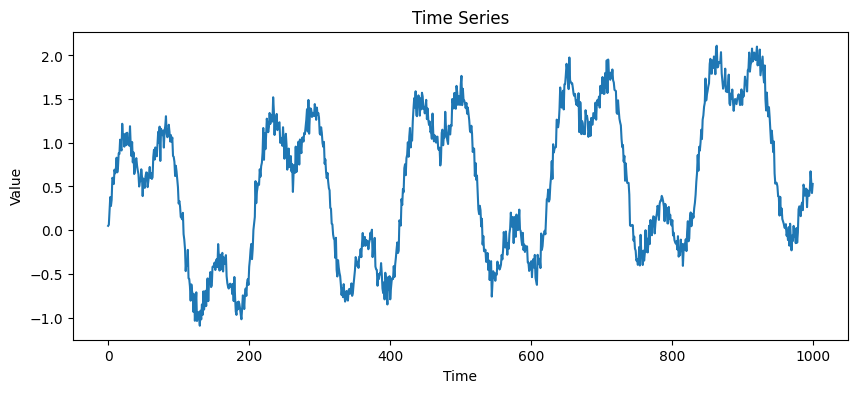

In [2]:
# A simple time series with trend, seasonality and noise
t = np.arange(1000)

series = (
    np.sin(t * 0.03)
    + 0.5 * np.sin(t * 0.09)
    + 0.001 * t
    + 0.1 * np.random.randn(1000)
)

df = pd.DataFrame({"value": series})

plt.figure(figsize=(10, 4))
plt.plot(df["value"])
plt.title("Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

## 2. Create Input Sequences

In [3]:
window = 32

X = []
y = []

for i in range(len(series) - window):
    X.append(series[i:i + window])
    y.append(series[i + window])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# First 80% for training, remaining 20% for testing
split = int(0.8 * len(X))

X_train = torch.tensor(X[:split]).unsqueeze(1)
y_train = torch.tensor(y[:split]).unsqueeze(1)

X_test = torch.tensor(X[split:]).unsqueeze(1)
y_test = torch.tensor(y[split:]).unsqueeze(1)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: torch.Size([774, 1, 32])
Testing shape : torch.Size([194, 1, 32])


## 3. Custom Dilated Causal Convolution

Causal convolution uses **left padding only**, so the output at time `t` cannot see future values.


In [4]:
class CausalConv1D(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()

        self.padding = (kernel_size - 1) * dilation

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            dilation=dilation
        )

    def forward(self, x):
        # Pad only the left side.
        x = F.pad(
            x,
            (self.padding, 0)
        )

        return self.conv(x)

## 4. Simple TCN

In [5]:
class TCN(nn.Module):

    def __init__(self):
        super().__init__()

        self.layers = nn.ModuleList()

        channels = 16
        dilations = [1, 2, 4, 8, 16]

        in_channels = 1

        for d in dilations:

            self.layers.append(
                CausalConv1D(
                    in_channels,
                    channels,
                    kernel_size=3,
                    dilation=d
                )
            )

            in_channels = channels

        self.fc = nn.Linear(
            channels,
            1
        )

    def forward(self, x):

        for layer in self.layers:
            x = torch.relu(layer(x))

        # Use the last time step for prediction.
        x = x[:, :, -1]

        return self.fc(x)


tcn = TCN().to(device)

print(tcn)

TCN(
  (layers): ModuleList(
    (0): CausalConv1D(
      (conv): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
    )
    (1): CausalConv1D(
      (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), dilation=(2,))
    )
    (2): CausalConv1D(
      (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), dilation=(4,))
    )
    (3): CausalConv1D(
      (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), dilation=(8,))
    )
    (4): CausalConv1D(
      (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), dilation=(16,))
    )
  )
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


## 5. Train the TCN

In [6]:
optimizer = torch.optim.Adam(
    tcn.parameters(),
    lr=0.001
)

loss_function = nn.MSELoss()

tcn_losses = []

X_train = X_train.to(device)
y_train = y_train.to(device)

for epoch in range(50):

    tcn.train()

    prediction = tcn(X_train)

    loss = loss_function(
        prediction,
        y_train
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    tcn_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/50 "
            f"- Loss: {loss.item():.5f}"
        )

Epoch 10/50 - Loss: 0.64474
Epoch 20/50 - Loss: 0.53575
Epoch 30/50 - Loss: 0.38272
Epoch 40/50 - Loss: 0.28821
Epoch 50/50 - Loss: 0.18091


## 6. Simple Classical Sequential Model

In [7]:
class SimpleGRU(nn.Module):

    def __init__(self):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=16,
            batch_first=True
        )

        self.fc = nn.Linear(16, 1)

    def forward(self, x):

        # GRU expects batch, time, features
        x = x.transpose(1, 2)

        out, _ = self.gru(x)

        return self.fc(out[:, -1, :])


gru = SimpleGRU().to(device)

optimizer = torch.optim.Adam(
    gru.parameters(),
    lr=0.001
)

gru_losses = []

for epoch in range(50):

    prediction = gru(X_train)

    loss = loss_function(
        prediction,
        y_train
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    gru_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"GRU Epoch {epoch + 1}/50 "
            f"- Loss: {loss.item():.5f}"
        )

GRU Epoch 10/50 - Loss: 0.62098
GRU Epoch 20/50 - Loss: 0.51131
GRU Epoch 30/50 - Loss: 0.41393
GRU Epoch 40/50 - Loss: 0.32927
GRU Epoch 50/50 - Loss: 0.25742


## 7. Compare Training Loss

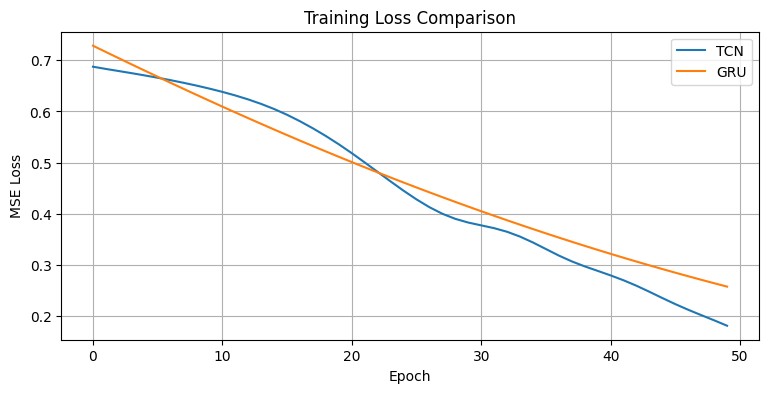

In [8]:
plt.figure(figsize=(9, 4))

plt.plot(tcn_losses, label="TCN")
plt.plot(gru_losses, label="GRU")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.show()

## 8. Compare Test Prediction Error

In [9]:
X_test = X_test.to(device)
y_test = y_test.to(device)

tcn.eval()
gru.eval()

with torch.no_grad():

    tcn_pred = tcn(X_test)
    gru_pred = gru(X_test)

tcn_mse = torch.mean(
    (tcn_pred - y_test) ** 2
).item()

gru_mse = torch.mean(
    (gru_pred - y_test) ** 2
).item()

print("TCN Test MSE:", tcn_mse)
print("GRU Test MSE:", gru_mse)

TCN Test MSE: 0.10375223308801651
GRU Test MSE: 0.3995349407196045


## 9. Plot Predictions

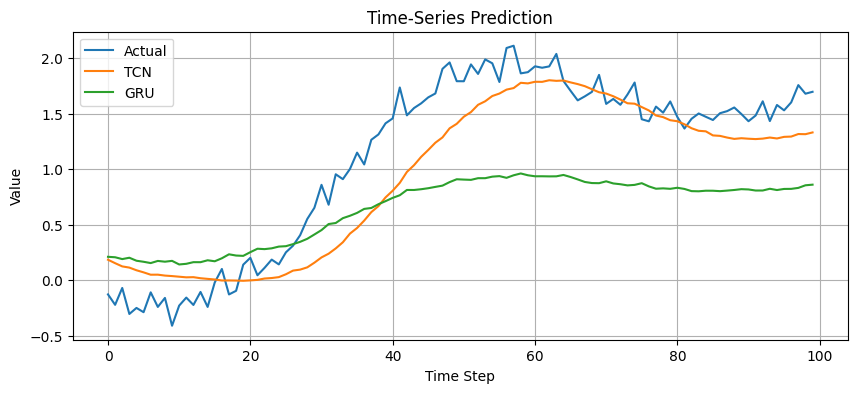

In [10]:
actual = y_test.cpu().numpy().flatten()

tcn_pred = tcn_pred.cpu().numpy().flatten()
gru_pred = gru_pred.cpu().numpy().flatten()

plt.figure(figsize=(10, 4))

plt.plot(actual[:100], label="Actual")
plt.plot(tcn_pred[:100], label="TCN")
plt.plot(gru_pred[:100], label="GRU")

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title("Time-Series Prediction")
plt.legend()
plt.grid()
plt.show()